# 6주차_데이터 전처리와 파생변수 생성 Ⅰ


- 이상치 처리


---

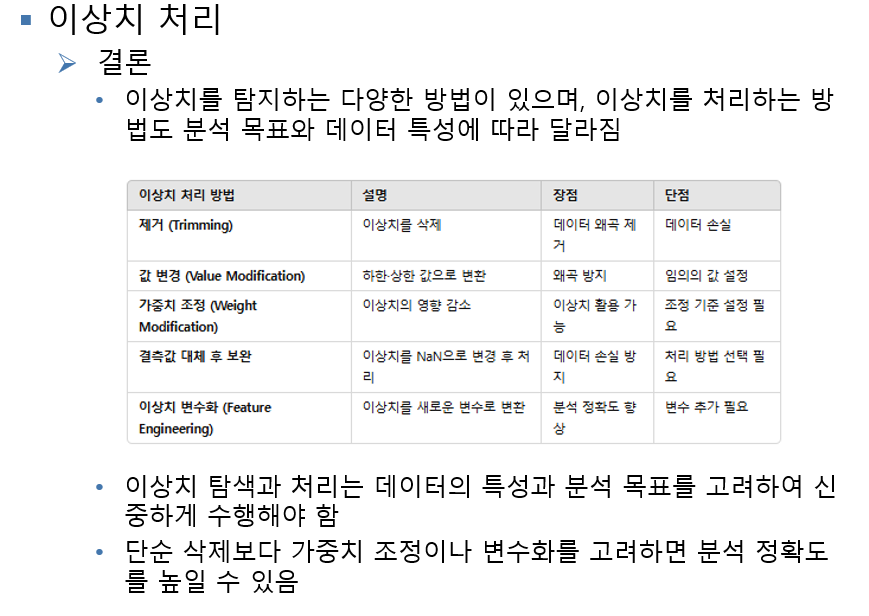

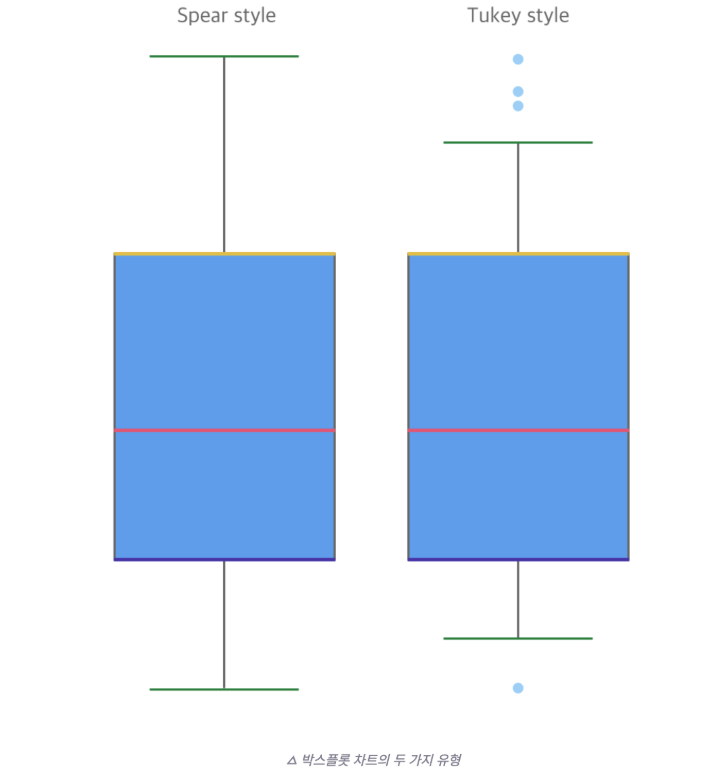 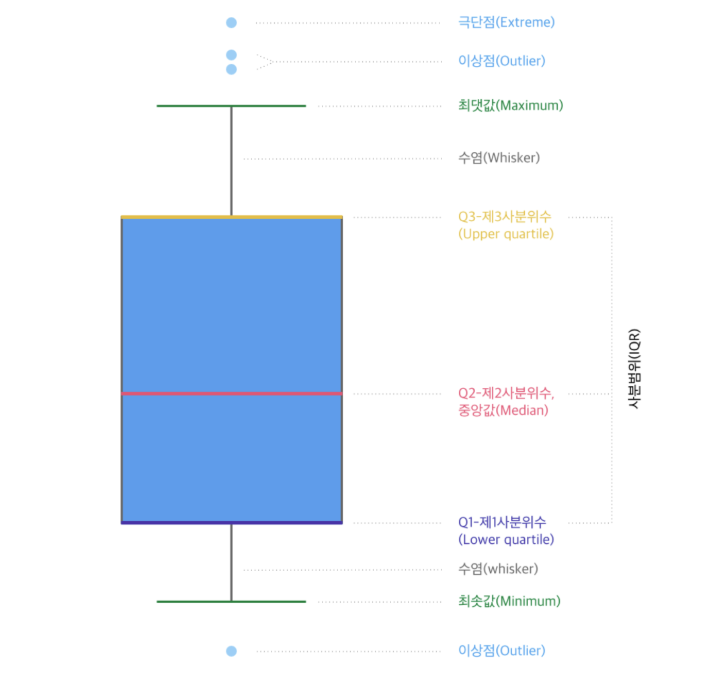

## 📌 박스플롯(Boxplot) 소개

### ✅ 박스플롯은 어떤 그래프인가요?

- **낯설어 보일 수 있지만, 실제로는 자주 사용되는 시각화 유형**
- 특히 **주식, 코인 등 투자**에서 흔히 보는 **캔들 차트(candlestick chart)**가 박스플롯의 변형 형태
- 데이터의 **분포와 이상치**를 한눈에 볼 수 있음

---

## 📦 박스플롯(Boxplot) 차트란?

### ✅ 박스플롯이란?

- **상자 및 수염 그림** (box and whisker plot), **상자그림**, **봉**, **캔들** 등 다양한 명칭으로 불림
- 주로 **주식 차트**, **통계학**, **논문** 등에서 사용됨

### 🔍 박스플롯의 구성 방식

- **Spear style**: 시가 ↔ 종가, 최댓값/최솟값으로 수염
- **Tukey style**: Q1~Q3 범위 기준, 이상치 외부 점으로 표시

---

## 🧭 박스플롯 스타일 비교

| 항목 | Spear style | Tukey style |
|--------|-------------|-------------|
| 🎯 목적 | 주로 주식 차트 표현 | 통계적 분포 및 이상치 식별 |
| 📦 박스 길이 | 시가 ↔ 종가 | Q1 ↔ Q3 |
| 📍 중앙값 | 포함 | 포함 |
| 📈 수염 | 최댓값~최솟값 | 이상치 제외한 최대/최소 |
| ⚠️ 이상치 | 미표시 | 점(dot)으로 표시 |

---

## 📐 박스플롯의 구성 원리: 통계 개념 기반

### 🔎 Tukey 스타일 선택 이유

- 이상치 식별에 탁월한 시각화
- 다섯숫자요약(Five-Number Summary) 기반

### 📊 다섯숫자요약 구성

1. 최솟값 (Minimum)  
2. 제1사분위수 (Q1)  
3. 중앙값 (Q2)  
4. 제3사분위수 (Q3)  
5. 최댓값 (Maximum)

---

## 🧱 박스플롯 구성 요소 정리

| 요소 | 설명 |
|------|------|
| Q1 | 하위 25% 지점 |
| Q2 | 중앙값 |
| Q3 | 상위 75% 지점 |
| IQR | Q3 - Q1 |
| Whisker | IQR 1.5배 이내 값 |
| Outlier | 수염 바깥의 값 |
| Extreme | 이상치 중 가장 멀리 떨어진 값 |

---

## 🎯 박스플롯의 핵심: 2사분위수(Q2)

- Q2는 전체의 중앙값으로 가장 중요한 위치
- 박스는 Q1~Q3 범위(IQR)를 나타냄
- 수염은 1.5×IQR 기준 바깥 값은 이상치로 간주

---

## 📌 박스플롯 사용의 이유와 주의사항

- 평균, 표준편차만 사용할 경우 왜곡 위험
- 이상치 시각화를 위해 박스플롯 필요
- 직관적으로는 어려울 수 있어 개념적 이해 필요

---

## 🔁 박스플롯 vs. 히스토그램

| 항목 | 히스토그램 | 박스플롯 |
|------|-------------|-----------|
| 목적 | 전체 분포 파악 | 요약 통계 및 이상치 탐색 |
| 구성 | 막대(bin), 도수 | 박스(IQR), 중앙값, 수염, 이상점 |
| 직관성 | 높음 | 개념적 이해 필요 |
| 이상치 표현 | 불가능 | 가능 |
| 밀집 분포 표현 | 우수 | 상대적으로 약함 |

---

In [1]:
# 필요한 패키지 설치
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plt.rcParams['figure.dpi'] = 300

In [2]:
# 데이터 불러오기
# https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease
df = pd.read_csv("../../main/datasets/heart_2020_cleaned.csv")

# 데이터 샘플 확인
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

In [4]:
df.shape

(319795, 18)

In [5]:
df.describe()

,BMI,PhysicalHealth,MentalHealth,SleepTime
count,319795.000000,319795.00000,319795.000000,319795.000000
mean,28.325399,3.37171,3.898366,7.097075
std,6.356100,7.95085,7.955235,1.436007
min,12.020000,0.00000,0.000000,1.000000
25%,24.030000,0.00000,0.000000,6.000000
50%,27.340000,0.00000,0.000000,7.000000
75%,31.420000,2.00000,3.000000,8.000000
max,94.850000,30.00000,30.000000,24.000000


In [6]:
df['BMI'].describe()
# 'BMI' 컬럼의 기초 통계량(최소값, 사분위수, 평균, 최대값 등)을 요약하여 확인함

count    319795.000000
mean         28.325399
std           6.356100
min          12.020000
25%          24.030000
50%          27.340000
75%          31.420000
max          94.850000
Name: BMI, dtype: float64

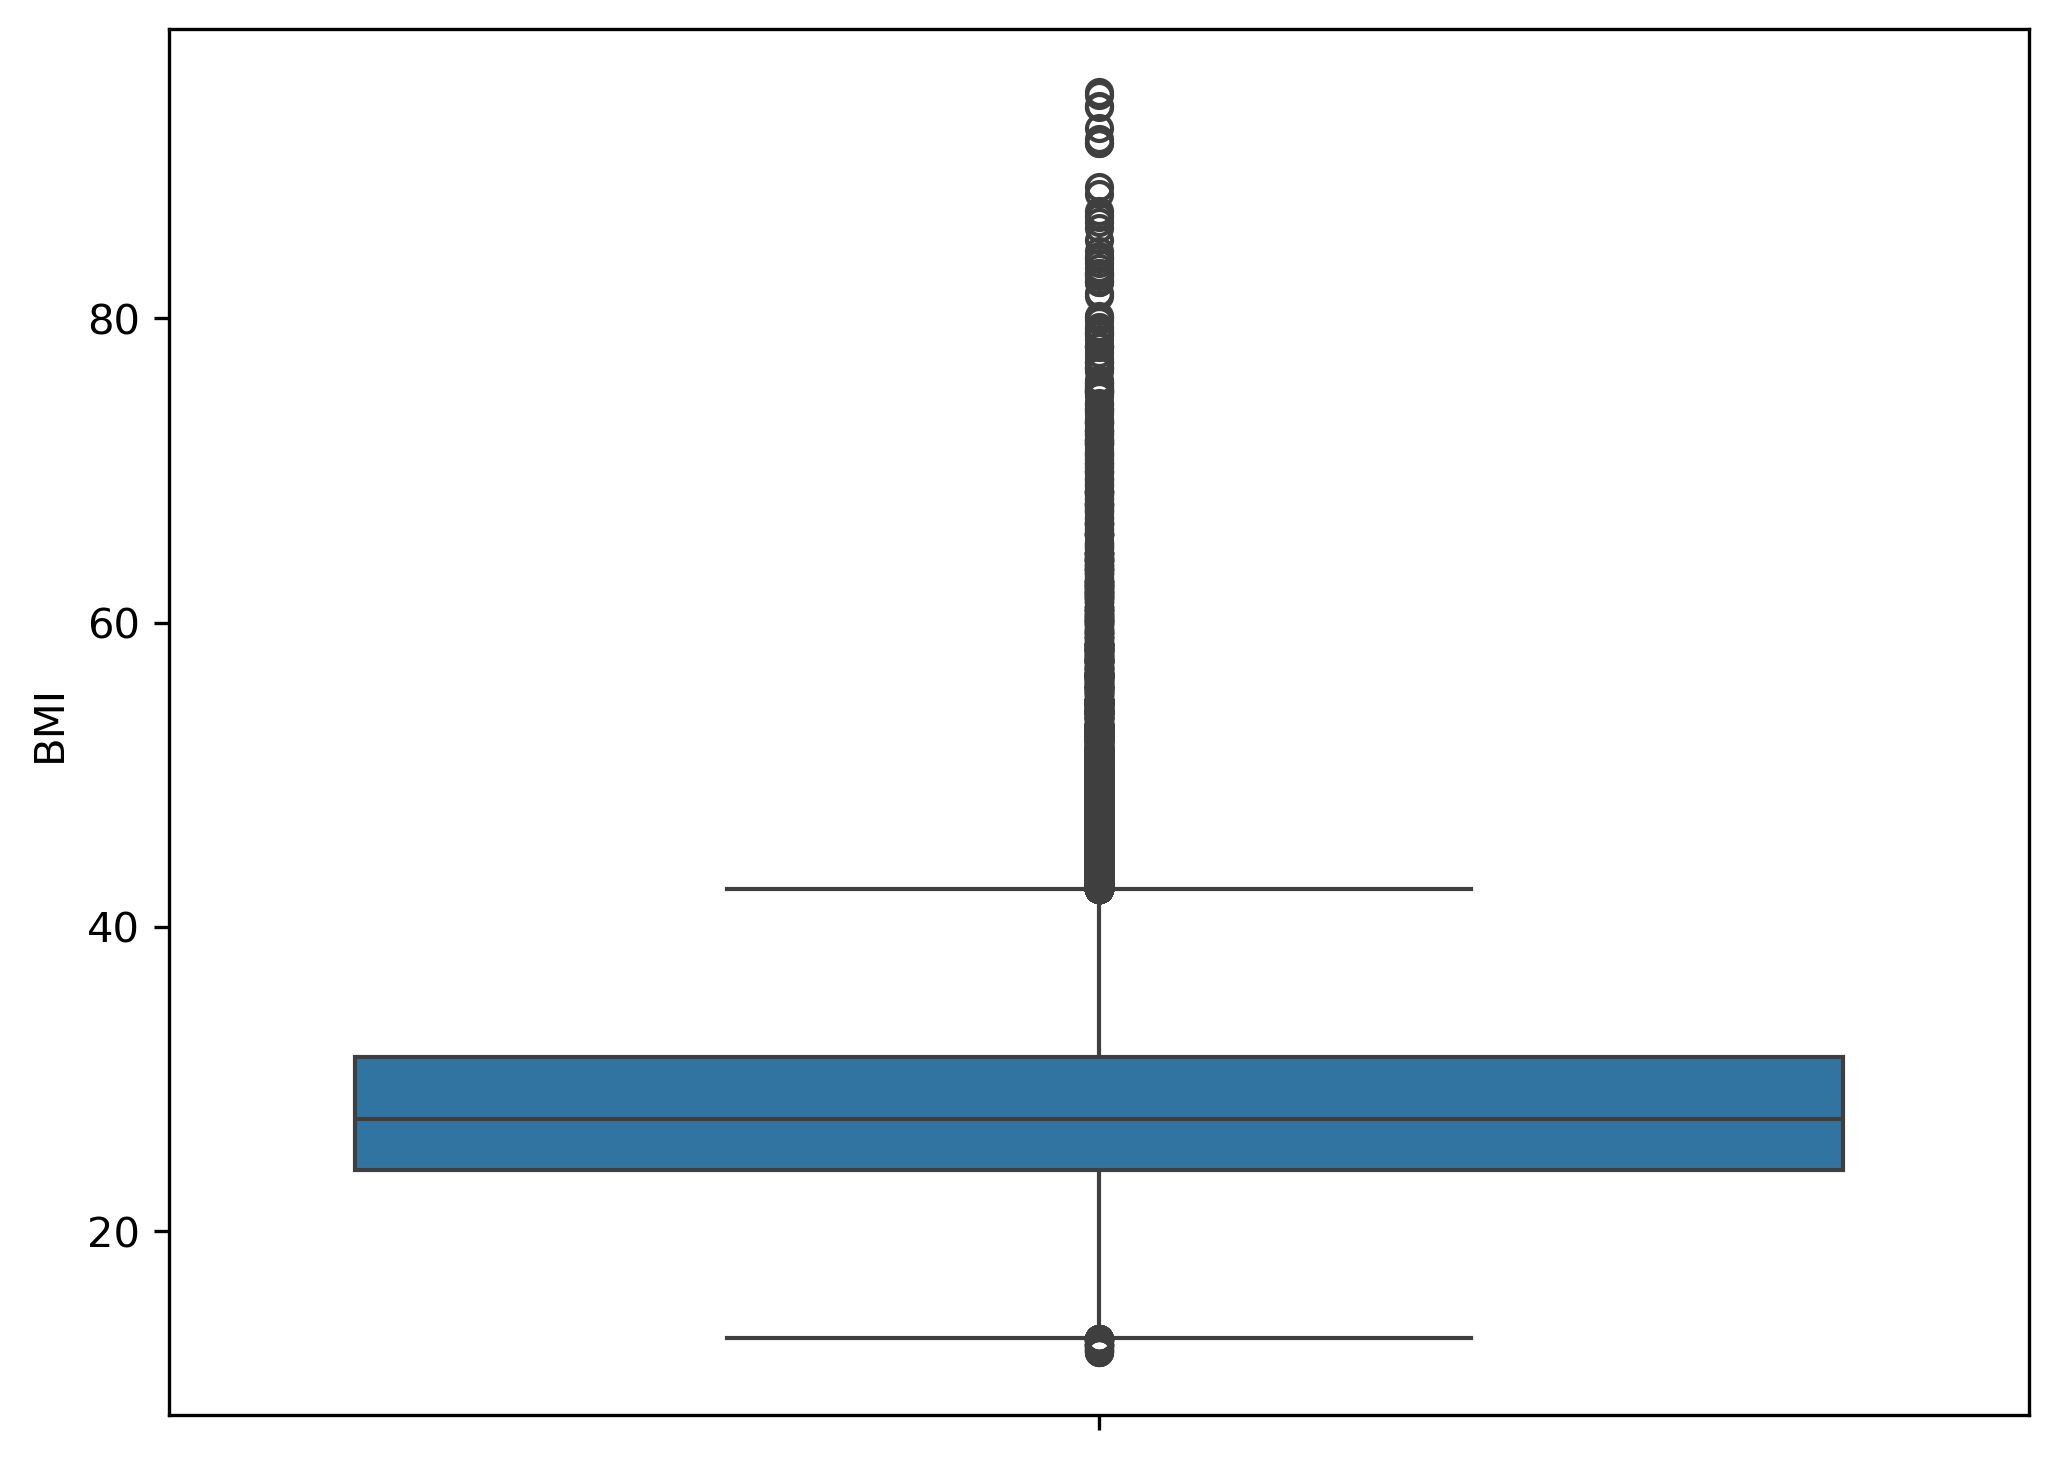

In [15]:
plt.figure(figsize=(8, 6))
sns.boxplot(y='BMI', data=df)
# 'BMI' 컬럼에 대해 박스플롯을 시각화하여 이상치 존재 여부를 직관적으로 확인함
plt.show()

---

### ✅ 1. Trim (제거)

- 이상치로 간주되는 값을 데이터셋에서 아예 삭제함.
- 정보 손실이 발생하지만 분포 왜곡을 줄이는 데 효과적임.

---

### ✅ 2. Winsorizing (윈저라이징)

- 변수의 최솟값과 최댓값을 특정 백분위수 값으로 잘라내어 상하 한계를 설정함.
- 극단값의 영향력을 제한하면서 전체 데이터 크기는 유지함.

---

### ✅ 3. Value Modification (값 대치)

- 이상치를 특정 값(예: 중앙값, IQR 경계값 등)으로 변경함.
- 데이터 보존과 이상치 영향 완화를 동시에 고려한 방식임.

---

### ✅ 4. Imputation (결측 대치)

- 이상치를 결측치로 처리한 뒤 평균, 중앙값, 모델 기반 예측값 등으로 대치함.
- 결측값 처리 기법을 응용하여 이상치를 보정함.

---

### ✅ 5. Binning (범주화)

- 연속형 변수의 값을 일정한 구간 또는 계급으로 나누어 범주형 변수로 변환함.
- 이상치를 포함한 극단값의 영향을 완화하며 해석을 용이하게 함.

---

In [16]:
# 🔍 사용한 방식: Trim (제거)

# 이상치 처리를 위해, IQR 계산

# BMI 컬럼의 이상치 제거 (IQR*3)

# Q1, Q3 범위 정의
Q1 = df['BMI'].quantile(0.25)
# 'BMI' 컬럼의 제1사분위수(25% 지점)를 계산함

Q3 = df['BMI'].quantile(0.75)
# 'BMI' 컬럼의 제3사분위수(75% 지점)를 계산함

IQR = Q3 - Q1
# 사분위 범위(IQR, Interquartile Range)를 계산함
# 이는 데이터의 중간 50% 범위를 의미하며 이상치 탐지 기준으로 활용됨

rev_range = 3
# 이상치 제거 범위 설정 계수를 3으로 지정함
# 일반적으로 1.5는 엄격한 기준, 3은 완화된 기준에 해당함

# 이상치 범위 설정
filter = (df['BMI'] >= Q1 - rev_range * IQR) & (df['BMI'] <= Q3 + rev_range * IQR)
# BMI 값이 (Q1 - IQR * 계수)보다 크거나 같고, (Q3 + IQR * 계수)보다 작거나 같은 값을 필터링 조건으로 지정함
# 해당 조건을 만족하지 않는 값은 이상치로 간주됨

df_rmv = df.loc[filter]
# 이상치가 아닌 정상 범위의 값만 남긴 새로운 데이터프레임(df_rmv)을 생성함

print(df['BMI'].describe())
# 이상치 제거 전 원본 BMI 컬럼의 기초 통계량을 출력함

print(df_rmv['BMI'].describe())
# 이상치 제거 후 필터링된 BMI 컬럼의 기초 통계량을 출력함
# 평균, 최소/최댓값, 사분위수의 변화를 통해 이상치의 영향을 확인 가능함


count    319795.000000
mean         28.325399
std           6.356100
min          12.020000
25%          24.030000
50%          27.340000
75%          31.420000
max          94.850000
Name: BMI, dtype: float64
count    318477.000000
mean         28.193173
std           6.010014
min          12.020000
25%          24.020000
50%          27.320000
75%          31.320000
max          53.590000
Name: BMI, dtype: float64


Before Trimming: (319795, 18)
After  Trimming: (309399, 18)


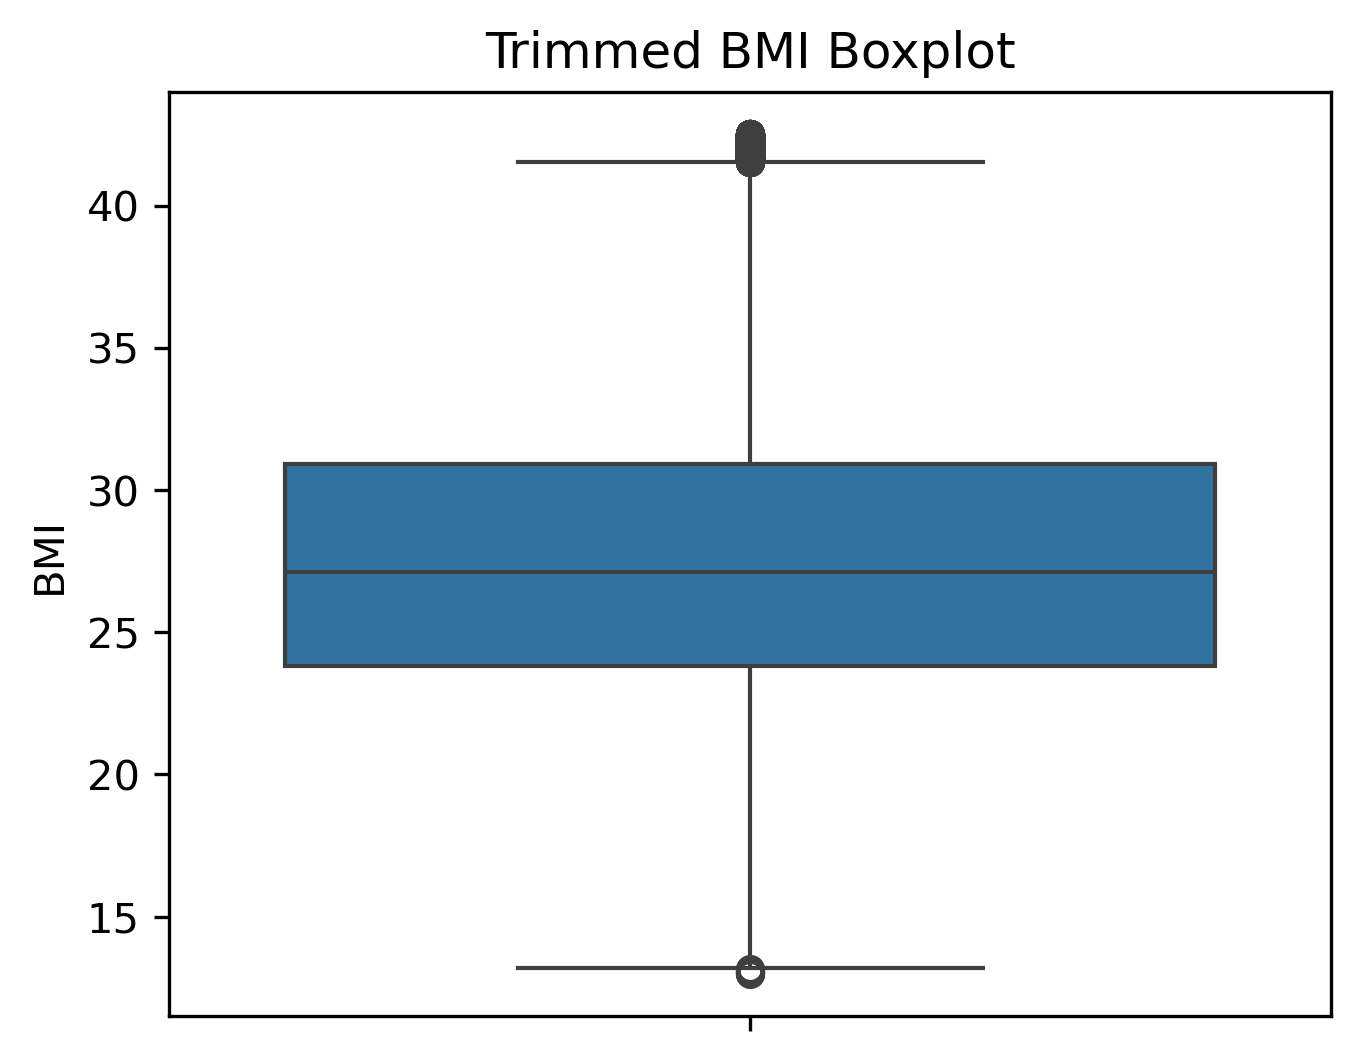

In [9]:
# Trimming (이상치 행 제거)

# 개념: 일정 기준을 벗어난 행 자체를 제거
# 장점: 간단하고, 이상치가 극도로 심할 경우 분석에 끼치는 영향을 제거
# 단점: 데이터 손실이 발생

# ---------------------------------------------

# 예: IQR 기준 1.5배 범위 밖 (또는 3배 등 필요에 따라 조절) 데이터 제거
rev_range = 1.5
# 이상치를 정의할 때 사용할 IQR 배수를 1.5로 설정함
# 1.5는 통계적으로 일반적인 이상치 탐지 기준이며, 너무 느슨하거나 엄격하지 않은 범위임

lower_bound = Q1 - rev_range * IQR
# 이상치를 판단하기 위한 하한값을 계산함
# 이보다 작으면 이상치로 간주함

upper_bound = Q3 + rev_range * IQR
# 이상치를 판단하기 위한 상한값을 계산함
# 이보다 크면 이상치로 간주함

condition = (df['BMI'] >= lower_bound) & (df['BMI'] <= upper_bound)
# BMI 값이 하한값 이상이고 상한값 이하인 조건을 정의함
# 즉, IQR 기준 범위 내에 해당하는 정상 값만 필터링함

df_trimmed = df[condition].copy()
# 위 조건을 만족하는 값들만 추출하여 새로운 데이터프레임(df_trimmed)을 생성함
# copy()를 사용하여 원본 df와의 참조 관계를 끊음

print("Before Trimming:", df.shape)
# 이상치 제거 전 전체 데이터프레임의 크기를 출력함

print("After  Trimming:", df_trimmed.shape)
# 이상치 제거 후 남은 행 수를 출력함
# 두 출력값을 비교하여 제거된 이상치의 수를 확인할 수 있음

plt.figure(figsize=(5, 4))
# 그래프 크기를 가로 5인치, 세로 4인치로 설정함

sns.boxplot(y='BMI', data=df_trimmed)
# 이상치 제거 이후 BMI 컬럼의 박스플롯을 시각화함
# 이상치가 제거되어 상자 밖의 점이 사라졌는지 여부를 시각적으로 확인함

plt.title("Trimmed BMI Boxplot")
# 그래프 제목을 설정함

plt.show()
# 박스플롯을 화면에 출력함



Winsorizing Lower: 1.8599999999999994
Winsorizing Upper: 53.59


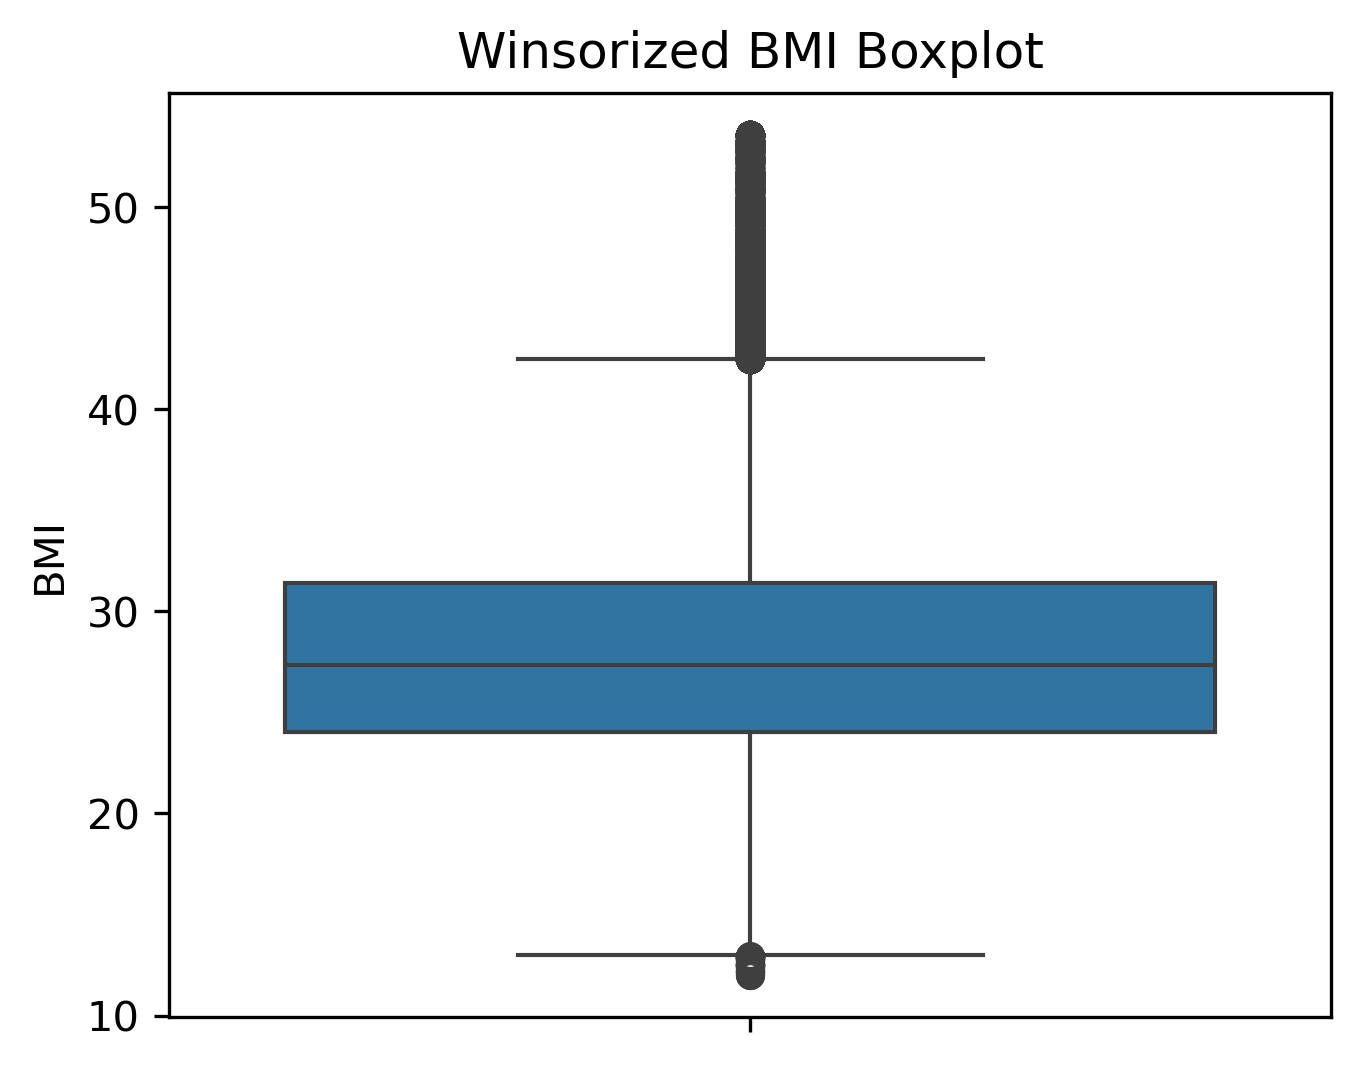

In [10]:
# Winsorizing (상하한값으로 ‘꽉' 조정)

# 개념: 이상치로 판단되는 값들을 제거하지 않고, 설정된 상한 및 하한으로 ‘강제 치환(클리핑)’
# 장점: 이상치를 제거하지 않으면서도 극단값이 전체 통계를 망치는 것을 방지
# 단점: 실제 데이터 분포가 왜곡될 수 있음

# ---------------------------------------------

import numpy as np
# 수치 연산 및 배열 처리 기능을 제공하는 numpy 패키지를 불러옴

df_winsor = df.copy()
# 원본 데이터프레임(df)을 그대로 보존하고, 윈저라이징 처리용 복사본(df_winsor)을 생성함

rev_range = 3.0
# 이상치 경계 허용 계수를 3으로 설정함
# 일반적인 이상치 처리 기준인 1.5보다 넓은 범위로 설정하여 덜 민감하게 처리함

winsor_lower = Q1 - rev_range * IQR
# BMI 값에서 허용 가능한 최소값을 계산함
# 제1사분위수보다 rev_range * IQR만큼 아래인 값으로 설정함

winsor_upper = Q3 + rev_range * IQR
# BMI 값에서 허용 가능한 최대값을 계산함
# 제3사분위수보다 rev_range * IQR만큼 위인 값으로 설정함

df_winsor['BMI'] = np.clip(df_winsor['BMI'], winsor_lower, winsor_upper)
# BMI 값이 상한보다 크거나 하한보다 작은 경우 각각 경계값으로 잘라냄
# 데이터 수를 유지하면서 극단값의 영향을 완화하는 목적임
# | 처리 방식 | 설명 |
# | --- | --- |
# | `np.clip()` | 지정된 상하한을 기준으로 값을 잘라냄 (절단 대치 방식) |
# | 목적 | 극단값 영향 최소화 + 전체 데이터 보존 |
# | 차이점 | 제거(drop)와 달리 관측치를 유지함, 대치(median 등)과 달리 원본 값 보존 성격이 강함 |

print("Winsorizing Lower:", winsor_lower)
# 하한 경계값을 출력하여 어떤 기준으로 잘라냈는지 확인함

print("Winsorizing Upper:", winsor_upper)
# 상한 경계값을 출력하여 윗쪽 잘림 기준을 확인함

plt.figure(figsize=(5, 4))
# 그래프 크기를 가로 5인치, 세로 4인치로 설정함

sns.boxplot(y='BMI', data=df_winsor)
# 윈저라이징된 BMI 데이터를 기반으로 박스플롯을 시각화함
# 이상치 점이 줄어들거나 없어졌는지 시각적으로 확인함

plt.title("Winsorized BMI Boxplot")
# 시각화에 제목을 부여하여 그래프의 의미를 명시함

plt.show()
# 그래프를 화면에 출력함


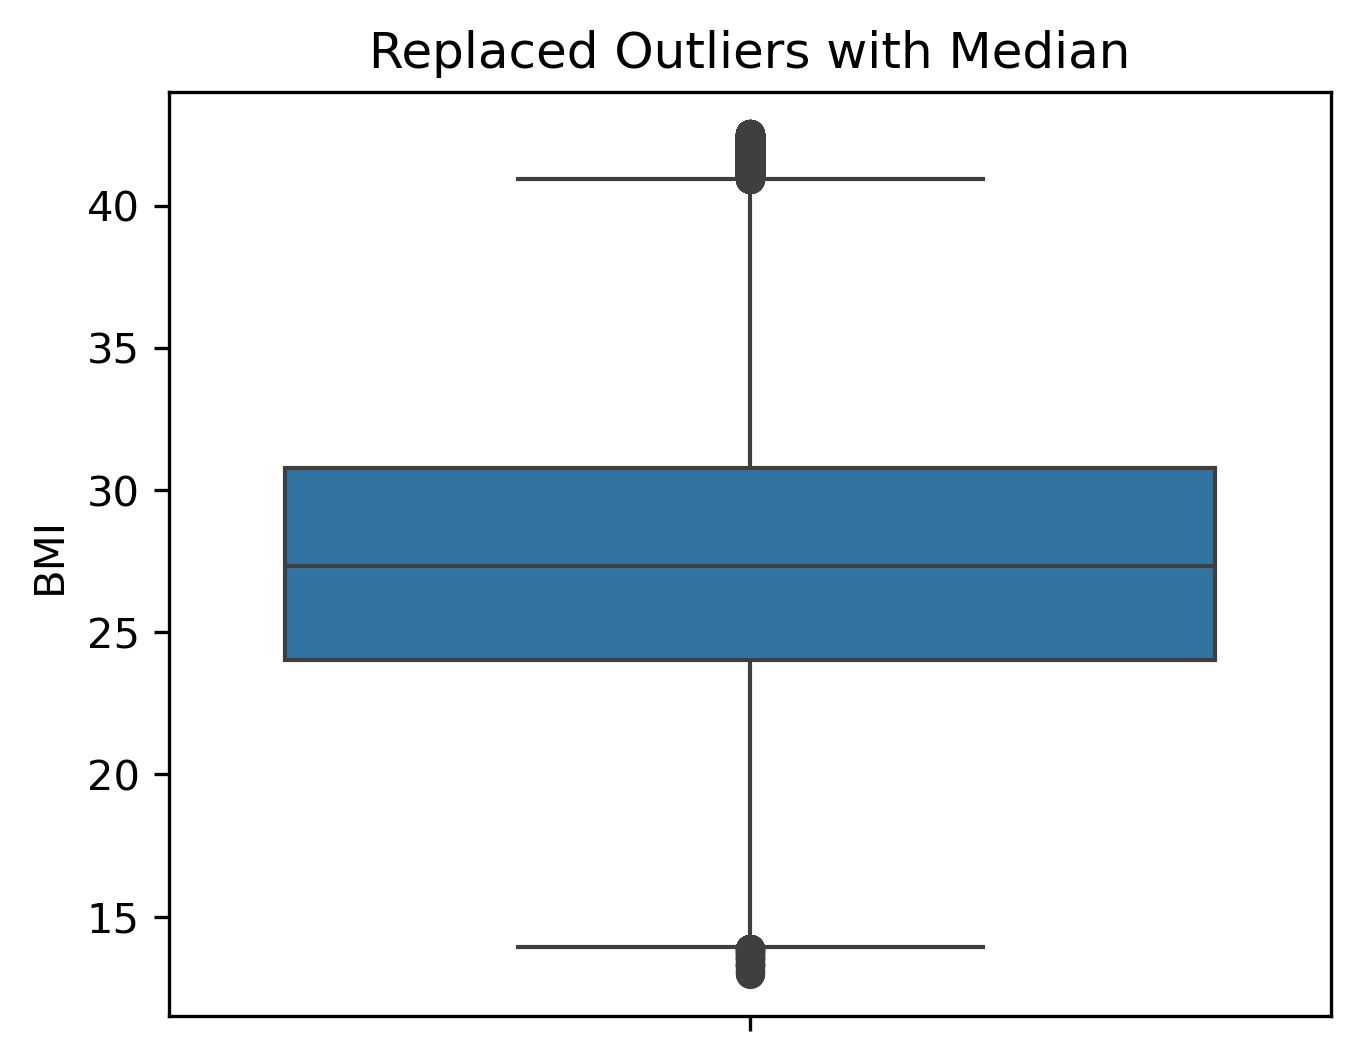

In [11]:
# Value Modification (특정값으로 대치)

# 개념: 이상치로 분류된 값을 중앙값, 평균값 등 임의의 대표값으로 대치
# 장점: 이상치를 제거하지 않고 유지하며, 대표값으로 치환하므로 분산이 너무 커지는 것을 방지
# 단점: 모든 이상치를 동일하게 처리하므로, 실제 분포가 왜곡될 위험이 있음

# ---------------------------------------------

df_replace = df.copy()
# 원본 데이터프레임(df)을 복사하여 중앙값 대치용 복사본(df_replace)을 생성함
# 이상치 처리 후 원본을 보존하기 위한 사전 조치임

median_bmi = df_replace['BMI'].median()
# 'BMI' 컬럼의 중앙값을 계산하여 변수로 저장함
# 이상치 대치에 사용할 기준값으로 활용됨
rev_range = 1.5
# IQR 경계 배수를 설정함
# 1.5배는 일반적인 Tukey 기준의 이상치 판단 경계값임
lower_bound = Q1 - rev_range * IQR
# 이상치 판단 하한선을 계산함
upper_bound = Q3 + rev_range * IQR
# 이상치 판단 상한선을 계산함

def replace_outlier_value(x):
    if x < lower_bound or x > upper_bound:
        return median_bmi
        # BMI 값이 IQR 기준 상·하한을 벗어나는 경우 중앙값으로 대치함
    else:
        return x
        # 정상 범위 값은 그대로 유지함


df_replace['BMI'] = df_replace['BMI'].apply(replace_outlier_value)
# 'BMI' 컬럼에 대해 이상치 판별 및 대치 함수를 적용함
# 이상치는 중앙값으로 교체되고 정상치는 유지됨


plt.figure(figsize=(5,4))
sns.boxplot(y='BMI', data=df_replace)
plt.title("Replaced Outliers with Median")
plt.show()


# # 이상치 IQR*3 값으로 대치

# # 이상치 대치 함수 설정
# def replace_outlier(value):
#     Q1 = df['BMI'].quantile(0.25)
#     Q3 = df['BMI'].quantile(0.75)
#     IQR = Q3 - Q1    #IQR 범위. 
#     rev_range = 3  # 제거 범위 조절 변수 설정

#     if ((value < (Q1 - rev_range * IQR))): 
#         value = Q1 - rev_range * IQR
#     if ((value > (Q3 + rev_range * IQR))): 
#         value = Q3 + rev_range * IQR
# #         value = df['BMI'].median() # 중앙값 대치
#     return value
# df['BMI'] = df['BMI'].apply(replace_outlier)

# print(df['BMI'].describe())


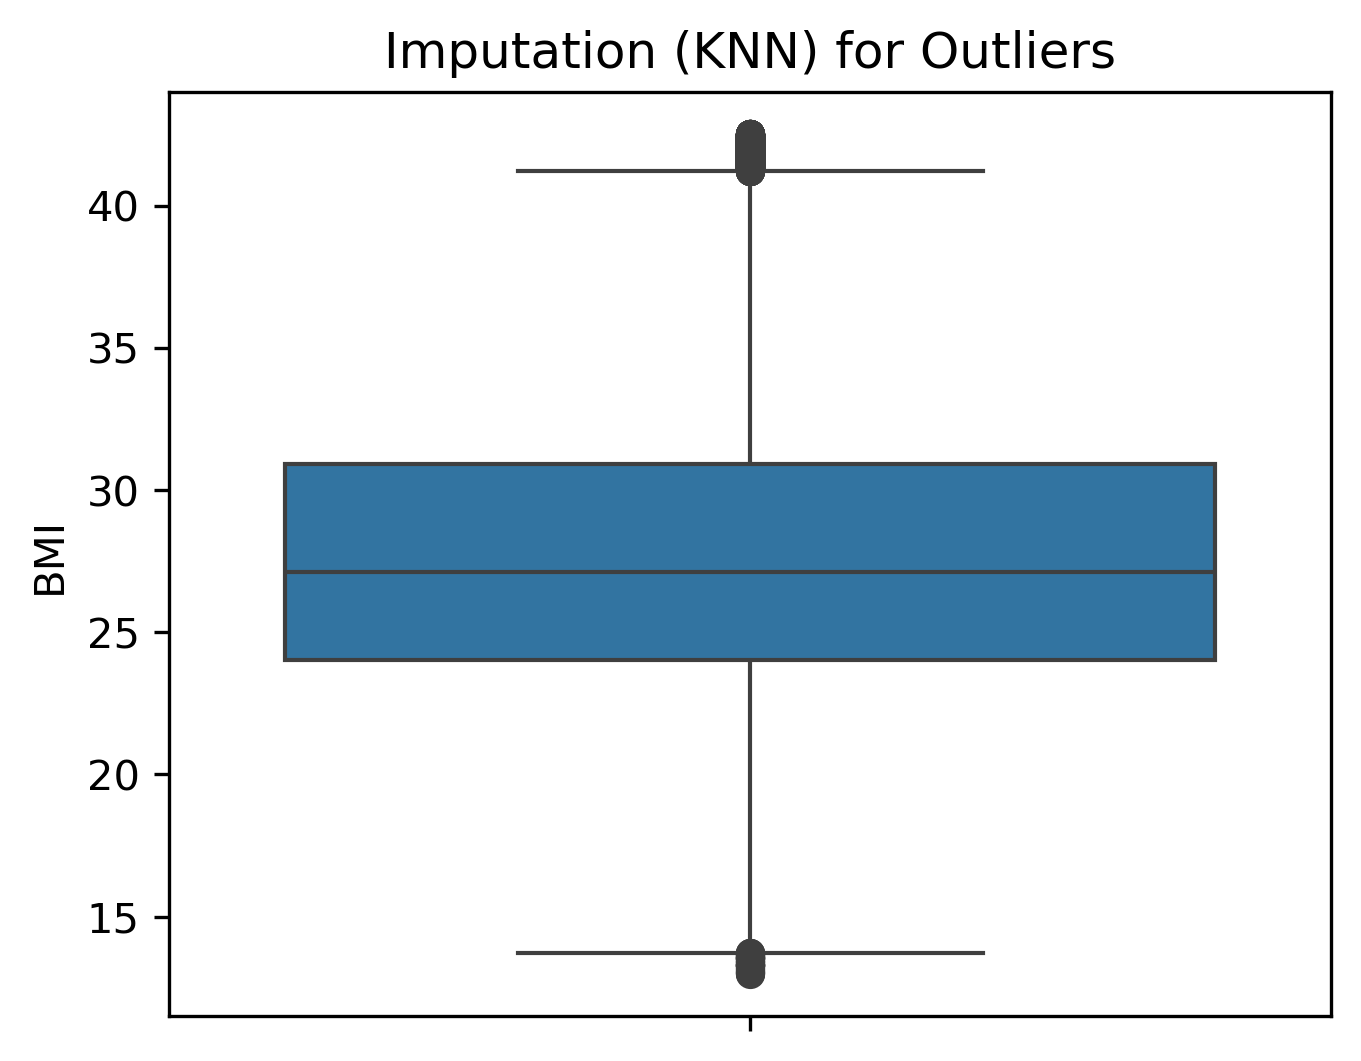

In [12]:
# Imputation (결측치로 처리 후, 추후 결측 대치)

# 개념: 이상치를 일단 결측치(NA)로 바꾼 다음, 결측치 처리(Imputation) 기법(평균/중앙값/최빈값 대치, KNN 대치 등)을 적용
# 장점: KNN Imputation 등 다양한 기법으로 보다 정교한 대치 가능
# 단점: Imputation 자체가 가정이 필요하므로, 부정확하면 오차가 누적될 수 있음

# ---------------------------------------------

from sklearn.impute import KNNImputer  
# scikit-learn에서 결측치 대치를 위한 KNNImputer 클래스 불러오기

df_imp = df.copy()  
# 원본 데이터프레임(df)을 복사하여 KNN 임퓨팅 처리를 적용할 df_imp 데이터프레임 생성
# 원본 보존을 위한 사전 조치 수행

rev_range = 1.5  
# 이상치 판단 기준을 위한 IQR 배수 설정
# 일반적으로 1.5배는 Tukey의 mild outlier 기준에 해당함
lower_bound = Q1 - rev_range * IQR  
# 이상치 판단을 위한 하한 경계값 계산
# Q1보다 rev_range * IQR 만큼 작은 값까지 허용 범위로 간주함
upper_bound = Q3 + rev_range * IQR  
# 이상치 판단을 위한 상한 경계값 계산
# Q3보다 rev_range * IQR 만큼 큰 값까지 허용 범위로 간주함
df_imp.loc[(df_imp['BMI'] < lower_bound) | (df_imp['BMI'] > upper_bound), 'BMI'] = np.nan  
# BMI 값이 하한보다 작거나 상한보다 클 경우 해당 값을 결측값(np.nan)으로 변경함
# 이상치를 결측값으로 처리하여 이후 대치를 적용할 준비를 함

imputer = KNNImputer(n_neighbors=5)  
# 최근접 이웃 5개를 기반으로 결측값을 대치하는 KNNImputer 객체 생성
# 결측값은 주변 5개 이웃의 평균으로 보완됨

cols = df_imp.columns  
# 데이터프레임의 원본 컬럼명을 저장함
# KNN 임퓨팅 후 결과를 다시 병합하거나 덮어쓰기할 때 사용됨

df_imp_imputed = pd.DataFrame(  
    imputer.fit_transform(df_imp.select_dtypes(include=['float64', 'int64'])),  
    columns=df_imp.select_dtypes(include=['float64', 'int64']).columns  
)  
# 1. df_imp에서 float64 또는 int64 타입의 수치형 컬럼만 선택하여 fit_transform에 전달함  
#    → KNNImputer는 범주형(object, bool 등) 처리 불가하므로 수치형만 별도로 선택함  
# 2. imputer.fit_transform()은 내부적으로 다음 절차를 수행함:  
#     - 각 결측값(np.nan)에 대해, 결측값이 없는 다른 샘플들과의 거리(유클리디안)를 계산함  
#     - 가장 가까운 n_neighbors(5개) 이웃을 선택함  
#     - 선택된 이웃들의 해당 feature 값의 평균을 계산하여 결측값을 대치함  
# 3. fit_transform의 결과는 numpy 배열이므로, 이를 pd.DataFrame으로 변환함  
#    → columns 인자로 원래의 수치형 컬럼명을 그대로 지정하여 컬럼명 복구 및 순서 보존함  
# 4. 이 결과물(df_imp_imputed)은 결측값이 모두 채워진 수치형 전용 데이터프레임이 됨  

for col in df_imp_imputed.columns:  
    df_imp[col] = df_imp_imputed[col]  
    # 반복문을 통해 수치형 컬럼들만 원래 복사본 df_imp에 덮어씀  
    # 기존 df_imp에는 범주형 컬럼들이 그대로 존재하고 있음 → 덮어쓰지 않음  
    # 결과적으로:  
    #   - 결측치가 존재했던 수치형 컬럼은 KNN으로 채워진 값으로 대체됨  
    #   - 범주형 컬럼은 원래 df에서 유지되므로 전체 데이터 구조와 행 수가 완전하게 보존됨  
    #   - 이 방식은 다중 타입 컬럼이 존재하는 실제 분석 환경에서 매우 안전하고 유효함  

plt.figure(figsize=(5,4))
sns.boxplot(y='BMI', data=df_imp)
plt.title("Imputation (KNN) for Outliers")
plt.show()



In [13]:
# Binning (범주화)

# 개념: 값의 범위를 여러 구간(bin)으로 나누어 범주형으로 변환
# 장점: 극단값 문제에서 자유로워지고, 범주별 특징 파악에 유리
# 단점: 연속형 정보 유실, 세분화 수준에 따라 결과가 달라짐

# ---------------------------------------------

df_bin = df.copy()  
# 원본 데이터프레임(df)을 복사하여 구간화 처리용 복사본(df_bin)을 생성함  
# 원본 보존을 위해 사본을 사용하는 방식 적용함  


# BMI 구간화 예시 (임의로 구간 설정 가능)
# 일반적인 BMI 분류 (WHO 기준과 약간 다를 수 있으니 예시)
# 저체중( <18.5 ), 정상(18.5~25), 과체중(25~30), 비만(30~)
bins = [0, 18.5, 25, 30, 100]  
# BMI를 분할할 경계값 리스트를 정의함  
# 0부터 100까지 BMI 값을 4개의 구간으로 나눔  
# 100은 BMI의 최대값 상한을 대략적으로 넉넉히 잡은 값임 (확실한 상한 필요 시 describe로 확인 가능함)

labels = ['Underweight','Normal','Overweight','Obese']  
# 각 구간에 대응할 라벨명을 설정함  
# BMI의 범주형 변환 결과가 해당 레이블로 표시되도록 구성함  

df_bin['BMI_category'] = pd.cut(df_bin['BMI'], bins=bins, labels=labels, right=False)  
# pd.cut() 함수를 이용해 BMI 값을 위에서 정의한 bins 기준으로 범주형 구간화함  
# right=False는 각 구간의 오른쪽 경계를 포함하지 않음을 의미함 → 예: 18.5는 Normal, 25는 Overweight로 분류됨  
# 결과는 BMI_category라는 새로운 컬럼으로 추가됨  

# 결과 확인
print(df_bin['BMI_category'].value_counts())
df_bin.head()

BMI_category
Overweight     114512
Obese          102842
Normal          97331
Underweight      5110
Name: count, dtype: int64


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer,BMI_category
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes,Underweight
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No,Normal
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No,Overweight
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes,Normal
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No,Normal


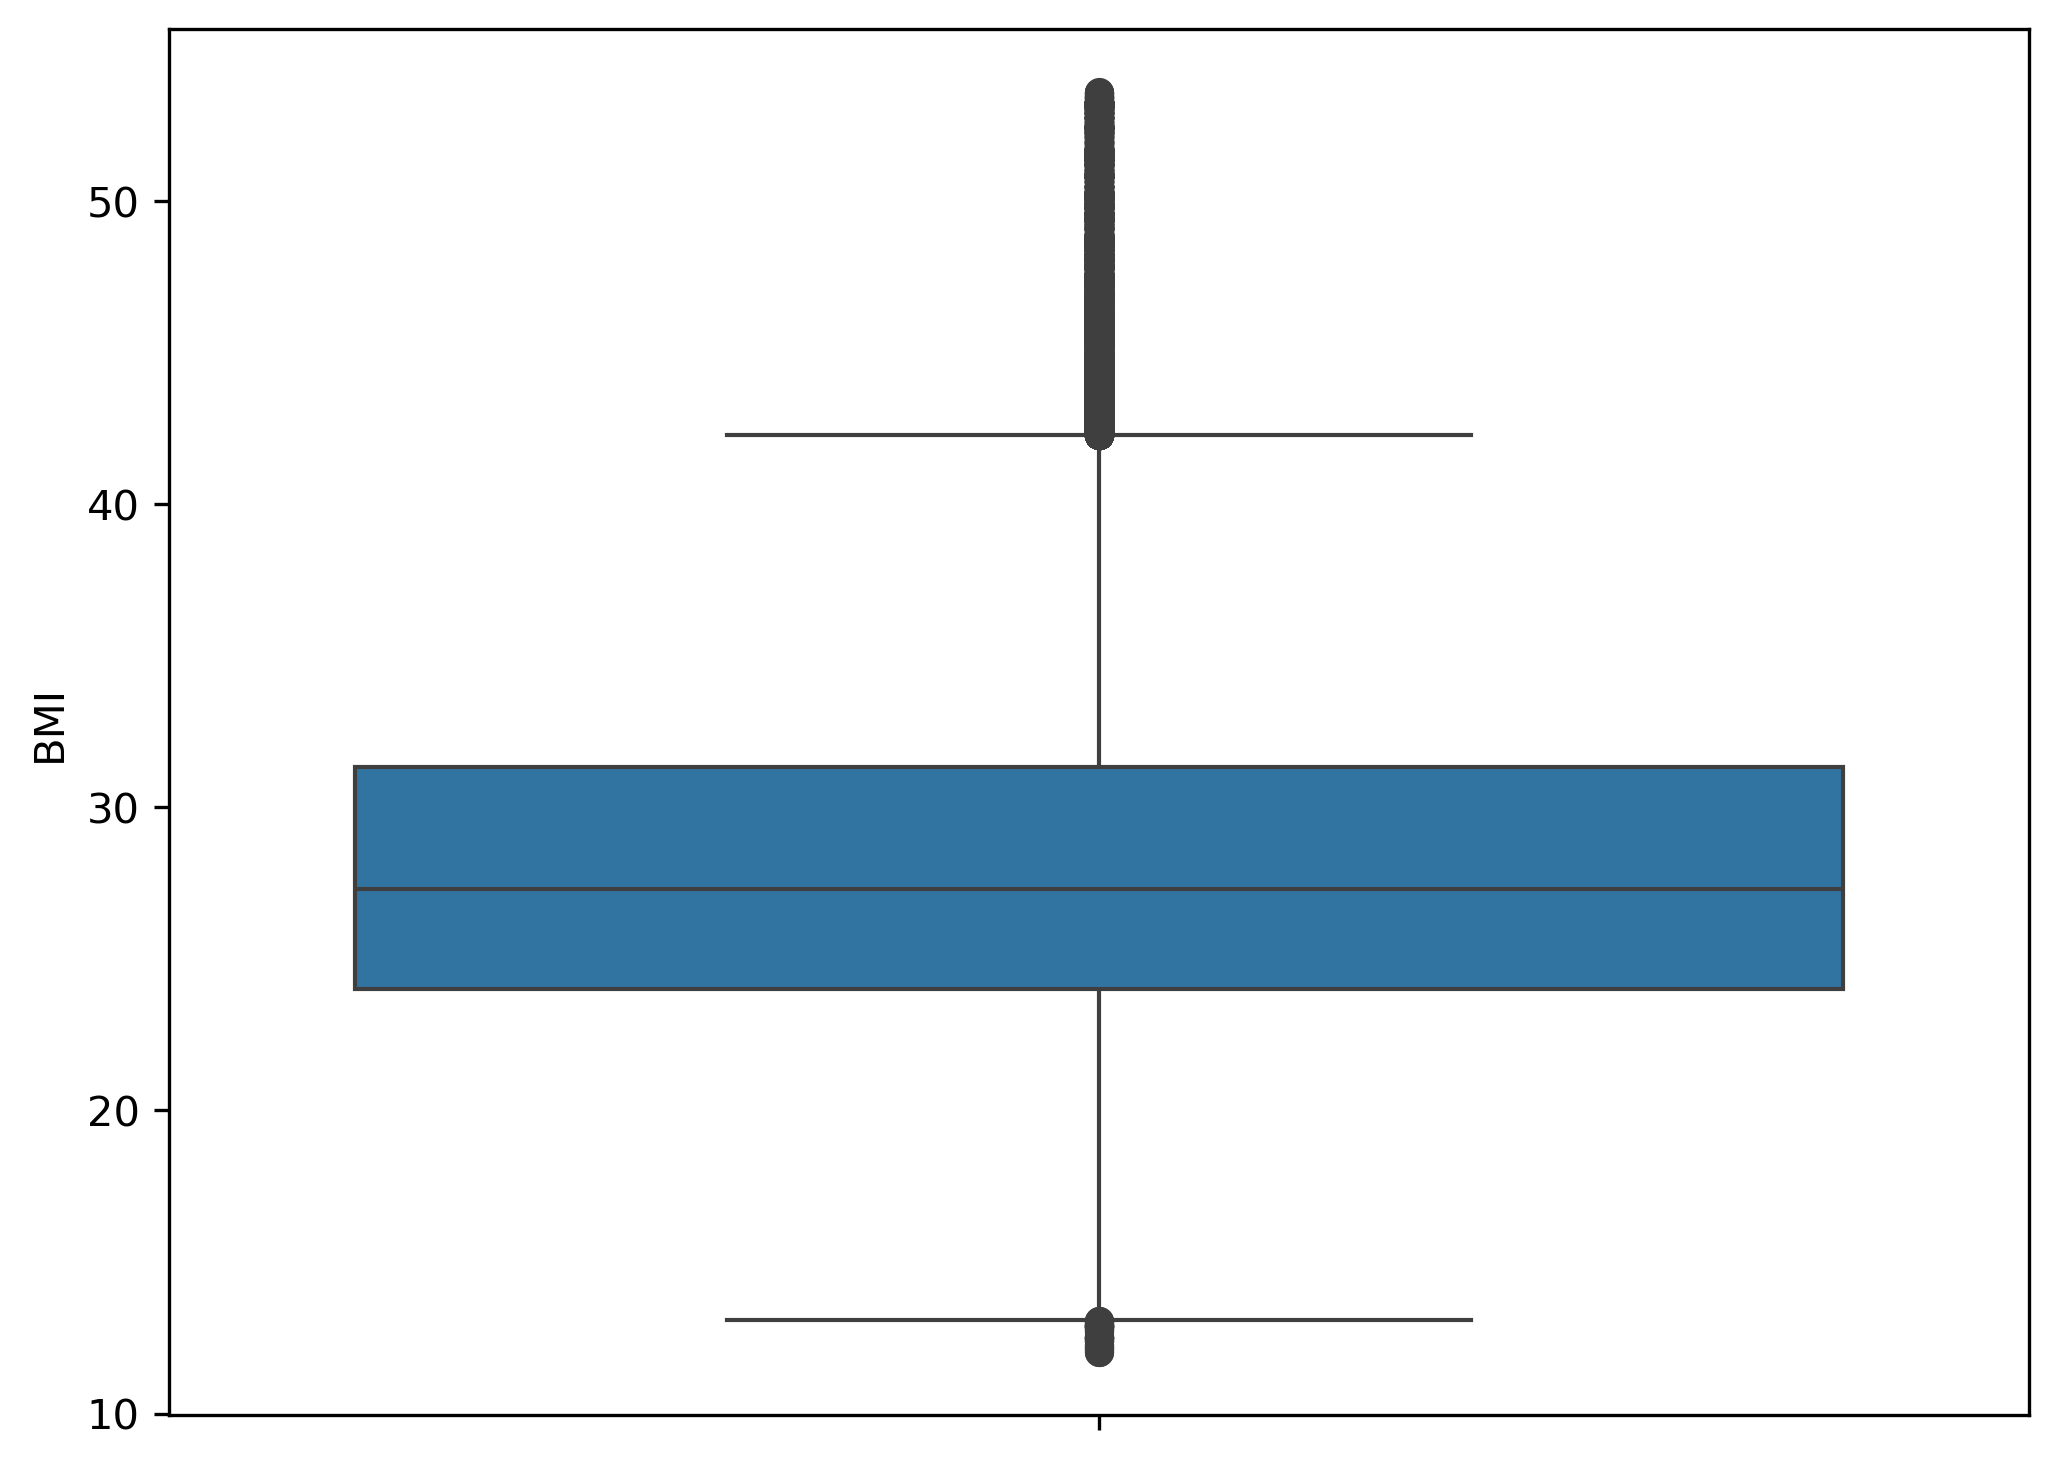

In [14]:
# 이상치 제거 후 박스플롯 시각화

plt.figure(figsize = (8, 6))
sns.boxplot(y = 'BMI', data = df_rmv)
plt.show()